# CS 229 - HW3 Extra Credit 2: Prediction Space Ablation

**Goal.** Compare three parameterizations of the same `EmojiViT` (no time conditioning):

- **x-prediction**: predict the clean image $\hat{x}$ (the baseline).
- **$\varepsilon$-prediction**: predict the noise $\hat{\varepsilon}$.
- **v-prediction**: predict the velocity $v = x - \varepsilon$.

All three describe the same straight-line flow, but they differ in how errors are weighted across $t$ and
how stable reconstruction is. Following Li & He (2025), Table 2, the key question is:
**does $\varepsilon$-prediction fail more badly without time conditioning?** Intuitively, recovering $\hat{x}$
from $\hat{\varepsilon}$ requires dividing by $t$, which blows up near $t \to 0$ (pure noise) where the
network has the least information.

## Setup (shared with `hw3-1.ipynb`)
Imports, data, model, and the reference flow-matching functions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%matplotlib inline
import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps') if torch.backends.mps.is_available() else device
print(f'Using device: {device}')
torch.manual_seed(229)

Using device: cuda


In [3]:
data = torch.load('/content/drive/My Drive/hw3_data_dedupe.pt', weights_only=False)
all_images = data['images']   # (N, 3, 32, 32) in [-1, 1]
names = data['names']

# Train/val split (fixed seed, identical to hw3-1)
torch.manual_seed(229)
perm = torch.randperm(len(all_images))
n_val = len(all_images) // 10
images = all_images[perm[n_val:]]
val_images = all_images[perm[:n_val]]
N = len(images)
print(f'Total: {len(all_images)} emoji, shape {all_images.shape}')
print(f'Train: {N}, Val: {len(val_images)}')


def show_grid(imgs, nrow=8, title=None, figsize=None):
    """Display images as a grid. imgs: (N, 3, H, W) in [-1, 1]."""
    imgs = imgs.detach().cpu().clamp(-1, 1)
    grid = make_grid((imgs + 1) / 2, nrow=nrow, padding=1, pad_value=1)
    if figsize is None:
        ncol = min(nrow, len(imgs))
        nrows = (len(imgs) + ncol - 1) // ncol
        figsize = (ncol * 1.5, nrows * 1.5 + 0.5)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    if title:
        plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Total: 1447 emoji, shape torch.Size([1447, 3, 32, 32])
Train: 1303, Val: 144


In [4]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block (no time conditioning)."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


class EmojiViT(nn.Module):
    """Vision Transformer for emoji generation. No time conditioning."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=256, depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(B, self.num_patches, -1)
        return x

    def unpatchify(self, x):
        B = x.shape[0]
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        x = x.reshape(B, h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        x = x.reshape(B, 3, h * p, w * p)
        return x

    def forward(self, x):
        x = self.patchify(x)
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        x = self.head(x)
        x = self.unpatchify(x)
        return x

In [5]:
def add_noise(x, t):
    """z_t = t * x + (1 - t) * eps, eps ~ N(0, I)."""
    noise = torch.randn_like(x)
    return t * x + (1 - t) * noise


def compute_loss(model, x):
    """Weighted x-prediction loss with logit-normal time sampling."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device))
    t = t.reshape(B, 1, 1, 1)
    z_t = add_noise(x, t)
    x_hat = model(z_t)
    return torch.mean(((x_hat - x) / (1 - t)) ** 2)


@torch.no_grad()
def sample(model, num_samples, T=100, device='cpu'):
    """Euler ODE sampler for the x-prediction model."""
    model.eval()
    z = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t_k = k / T
        v = (model(z) - z) / (1 - t_k)
        z = z + dt * v
    return torch.clamp(z, -1, 1)

## Losses for each parameterization
Recall $z_t = t x + (1-t)\varepsilon$ and velocity $v = x - \varepsilon$. Identities:
$\hat{x}_{(\varepsilon)} = (z_t - (1-t)\hat{\varepsilon})/t$ and $\hat{x}_{(v)} = z_t + (1-t)\hat{v}$.

In [6]:
def loss_x(model, x):
    """Weighted x-prediction loss (baseline)."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device)).reshape(B, 1, 1, 1)
    eps = torch.randn_like(x)
    z_t = t * x + (1 - t) * eps
    x_hat = model(z_t)
    return torch.mean(((x_hat - x) / (1 - t)) ** 2)


def loss_eps(model, x):
    """Epsilon-prediction: model output is eps_hat, plain MSE on noise."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device)).reshape(B, 1, 1, 1)
    eps = torch.randn_like(x)
    z_t = t * x + (1 - t) * eps
    eps_hat = model(z_t)
    return torch.mean((eps_hat - eps) ** 2)


def loss_v(model, x):
    """V-prediction: model output is v_hat, MSE on velocity v = x - eps."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device)).reshape(B, 1, 1, 1)
    eps = torch.randn_like(x)
    z_t = t * x + (1 - t) * eps
    v = x - eps
    v_hat = model(z_t)
    return torch.mean((v_hat - v) ** 2)

## Samplers
Each sampler converts the network output to a velocity for the same Euler integration. The
$\varepsilon$-sampler must divide by $t$, so we clamp $t$ to a small floor to expose (not hide) the
near-$t{=}0$ instability.

In [7]:
@torch.no_grad()
def sample_x(model, n, T=100, device='cpu', z0=None):
    model.eval()
    z = z0.clone() if z0 is not None else torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t = k / T
        v = (model(z) - z) / (1 - t)
        z = z + dt * v
    return z.clamp(-1, 1)


@torch.no_grad()
def sample_eps(model, n, T=100, device='cpu', z0=None):
    model.eval()
    z = z0.clone() if z0 is not None else torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t = max(k / T, 1e-3)            # floor avoids divide-by-zero at t=0
        eps_hat = model(z)
        x_hat = (z - (1 - t) * eps_hat) / t
        v = (x_hat - z) / (1 - t)
        z = z + dt * v
    return z.clamp(-1, 1)


@torch.no_grad()
def sample_v(model, n, T=100, device='cpu', z0=None):
    model.eval()
    z = z0.clone() if z0 is not None else torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        z = z + dt * model(z)           # output is velocity directly
    return z.clamp(-1, 1)

## Train all three

In [8]:
EPOCHS = 300
BATCH = 128
LR = 1e-3

def train(loss_fn, tag, epochs=EPOCHS):
    torch.manual_seed(229)
    model = EmojiViT().to(device)
    loader = DataLoader(TensorDataset(images), batch_size=BATCH, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    val = val_images.to(device)
    tr, vl = [], []
    for ep in range(epochs):
        model.train(); run = 0.0
        for (b,) in loader:
            b = b.to(device)
            loss = loss_fn(model, b)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()
        tr.append(run / len(loader))
        model.eval()
        with torch.no_grad():
            vl.append(loss_fn(model, val).item())
        if (ep + 1) % 50 == 0:
            print(f'[{tag}] epoch {ep+1}/{epochs}  train={tr[-1]:.4f}  val={vl[-1]:.4f}')
    return model, tr, vl

m_x, tr_x, vl_x = train(loss_x, 'x-pred')
m_eps, tr_eps, vl_eps = train(loss_eps, 'eps-pred')
m_v, tr_v, vl_v = train(loss_v, 'v-pred')

[x-pred] epoch 50/300  train=0.2597  val=0.2444
[x-pred] epoch 100/300  train=0.2231  val=0.2178
[x-pred] epoch 150/300  train=0.2055  val=0.2033
[x-pred] epoch 200/300  train=0.1910  val=0.2008
[x-pred] epoch 250/300  train=0.1877  val=0.1980
[x-pred] epoch 300/300  train=0.1753  val=0.1910
[eps-pred] epoch 50/300  train=0.0616  val=0.0574
[eps-pred] epoch 100/300  train=0.0517  val=0.0542
[eps-pred] epoch 150/300  train=0.0494  val=0.0510
[eps-pred] epoch 200/300  train=0.0417  val=0.0393
[eps-pred] epoch 250/300  train=0.0405  val=0.0411
[eps-pred] epoch 300/300  train=0.0374  val=0.0294
[v-pred] epoch 50/300  train=0.2861  val=0.2721
[v-pred] epoch 100/300  train=0.2505  val=0.2364
[v-pred] epoch 150/300  train=0.2298  val=0.2255
[v-pred] epoch 200/300  train=0.2155  val=0.2185
[v-pred] epoch 250/300  train=0.2051  val=0.2099
[v-pred] epoch 300/300  train=0.1968  val=0.2066


## Loss curves
Note: the three losses live on different scales (different targets), so compare each curve's *shape* and use the sample grids below for quality, not the absolute loss values across methods.

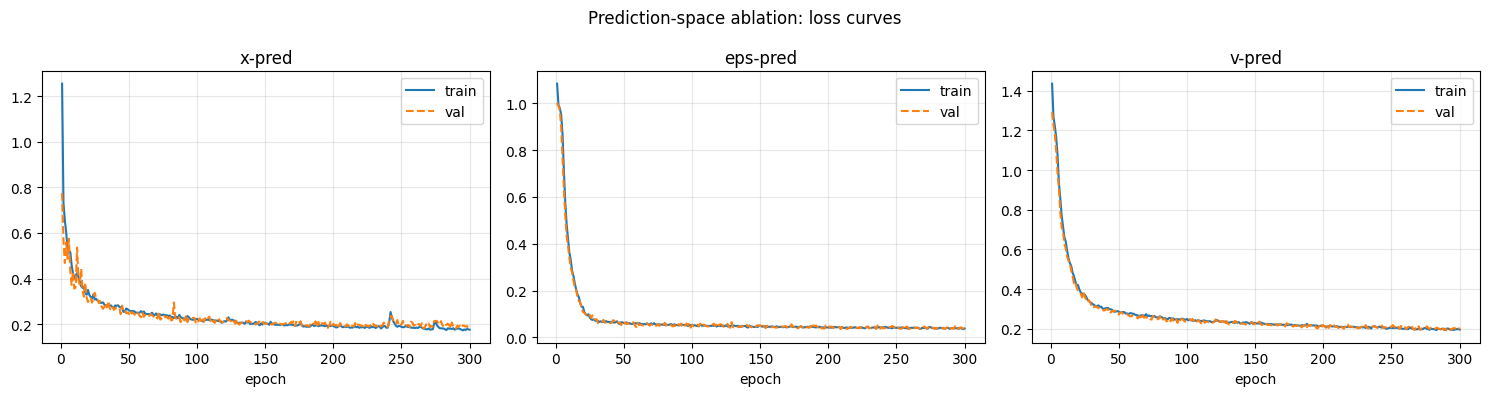

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tr, vl, name) in zip(axes, [(tr_x, vl_x, 'x-pred'), (tr_eps, vl_eps, 'eps-pred'), (tr_v, vl_v, 'v-pred')]):
    ax.plot(range(1, len(tr) + 1), tr, label='train')
    ax.plot(range(1, len(vl) + 1), vl, '--', label='val')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle('Prediction-space ablation: loss curves')
plt.tight_layout(); plt.show()

## Generated samples (same initial noise across methods)

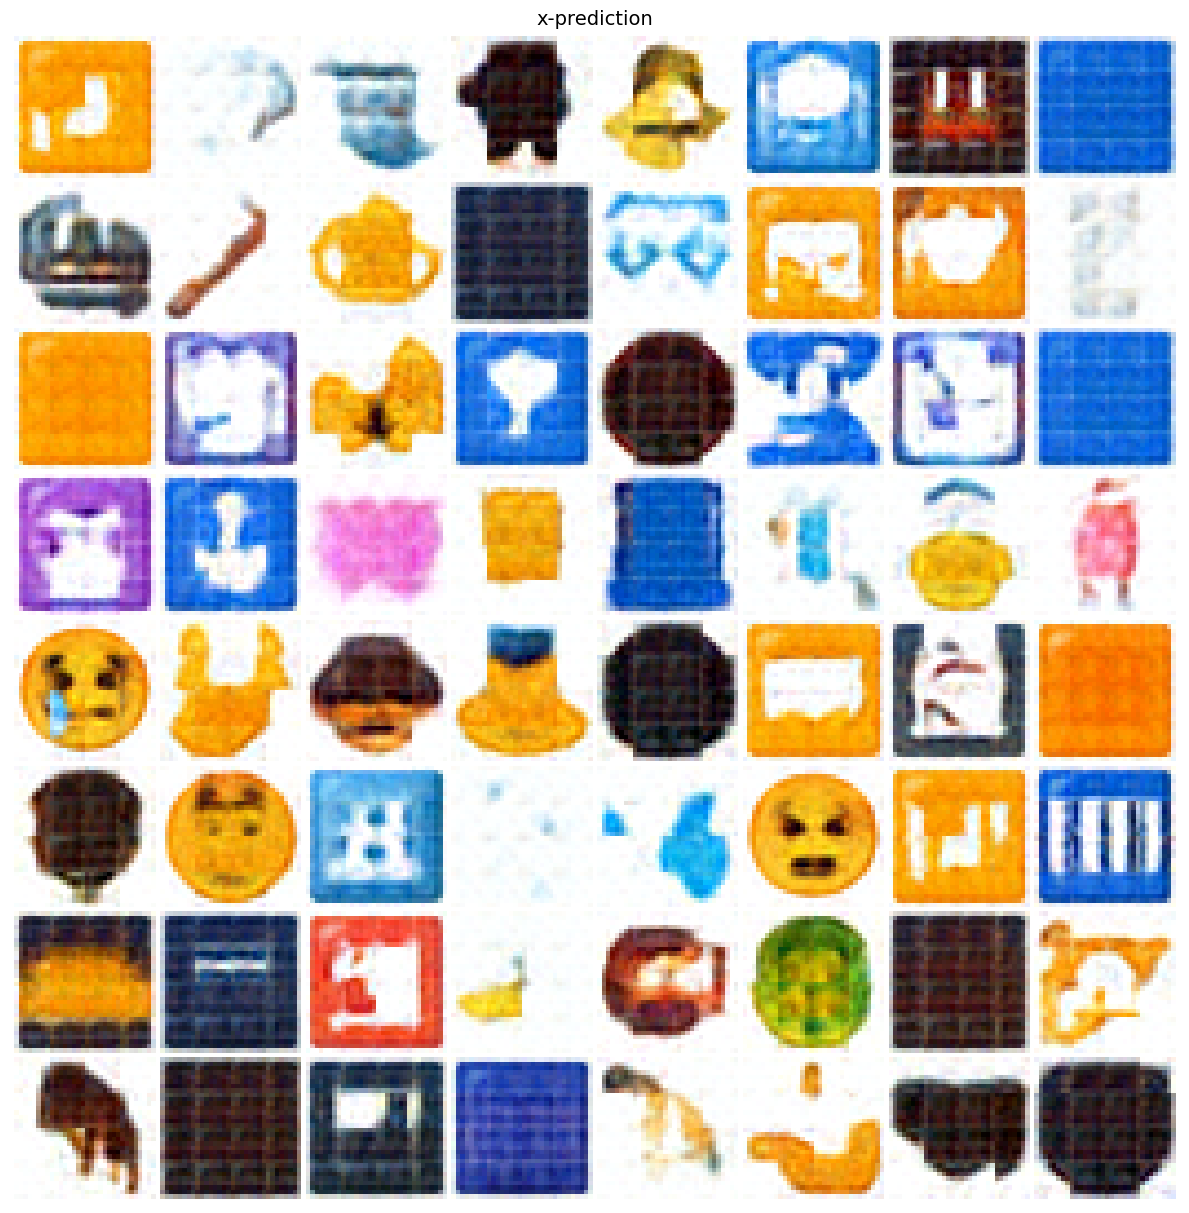

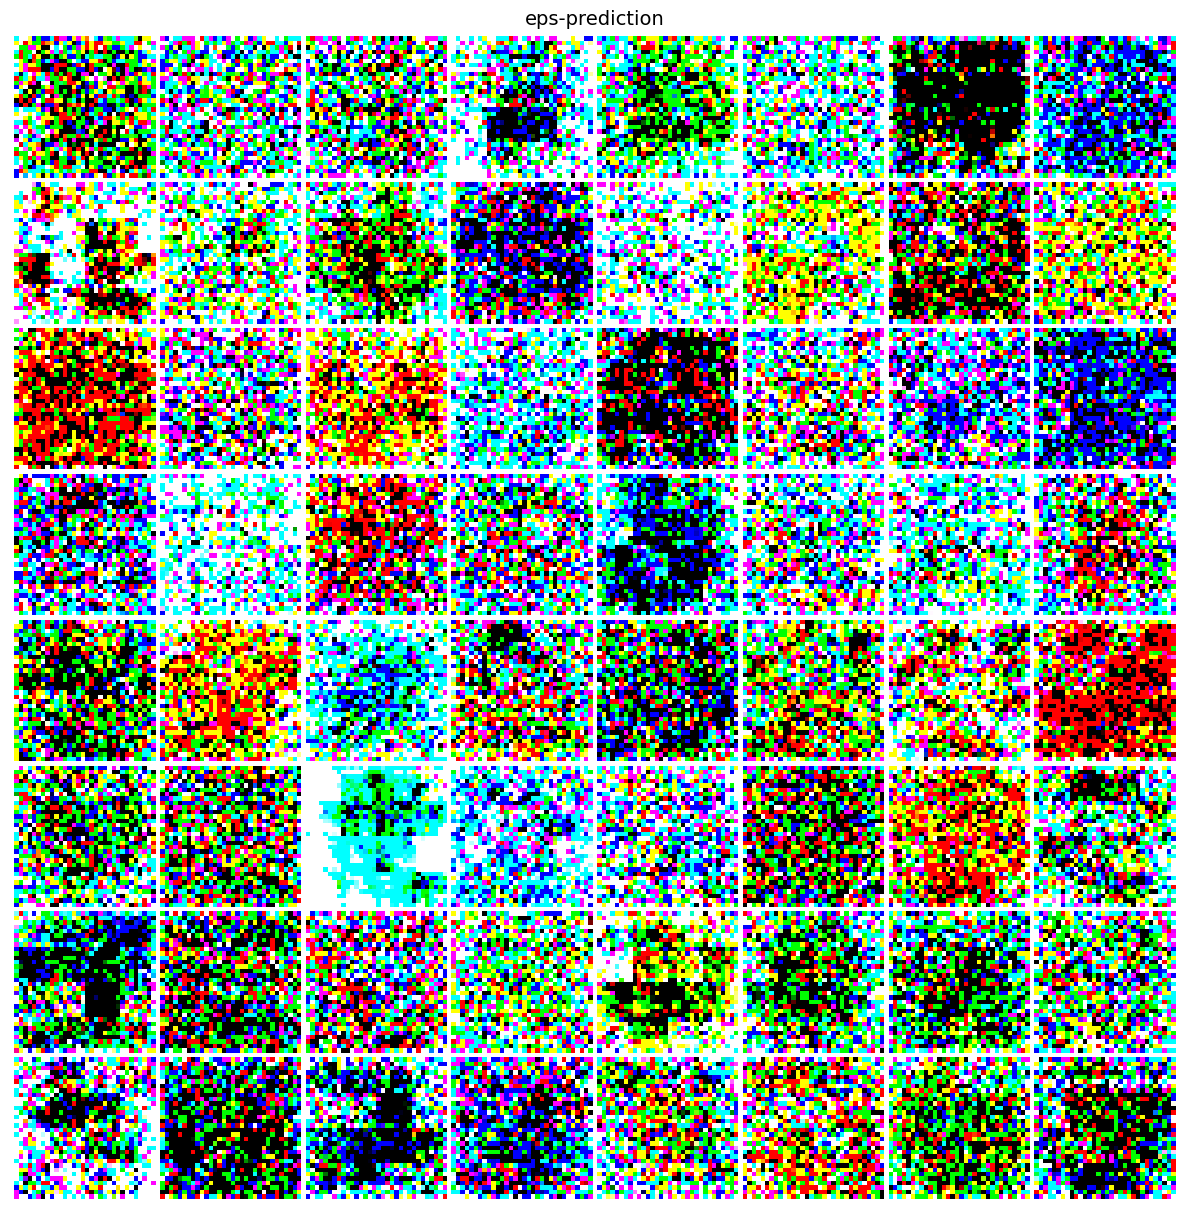

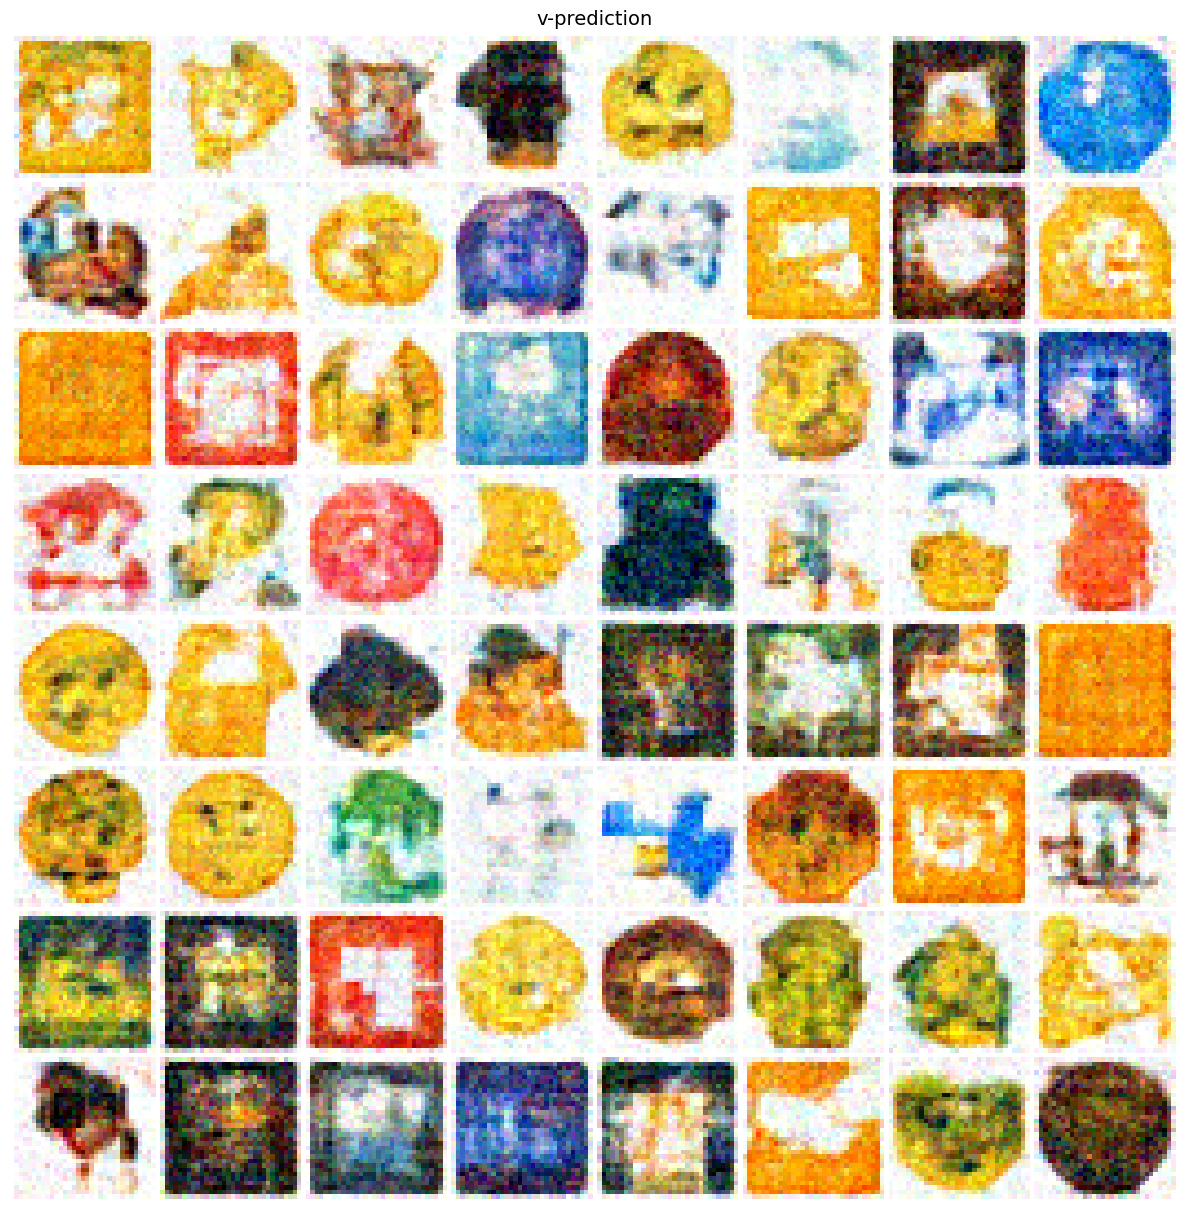

In [10]:
torch.manual_seed(7)
z0 = torch.randn(64, 3, 32, 32, device=device)
show_grid(sample_x(m_x, 64, 100, device, z0=z0.clone()), nrow=8, title='x-prediction')
show_grid(sample_eps(m_eps, 64, 100, device, z0=z0.clone()), nrow=8, title='eps-prediction')
show_grid(sample_v(m_v, 64, 100, device, z0=z0.clone()), nrow=8, title='v-prediction')

## Quantify the near-$t{=}0$ instability of $\varepsilon$-prediction
We measure the implied $\hat{x}$ reconstruction error as a function of $t$. For x- and v-prediction the
mapping to $\hat{x}$ is well-conditioned; for $\varepsilon$-prediction it scales like $1/t$.

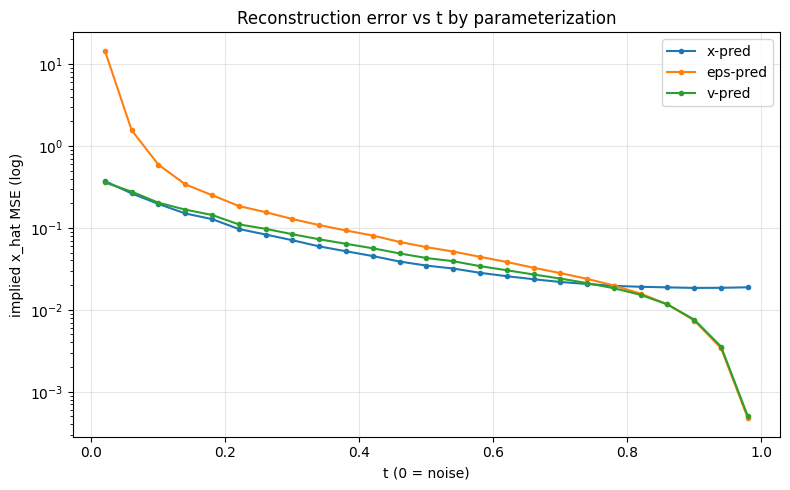

In [11]:
@torch.no_grad()
def recon_error_vs_t(ts=np.linspace(0.02, 0.98, 25), n=64):
    xb = images[:n].to(device)
    out = {'x-pred': [], 'eps-pred': [], 'v-pred': []}
    for tv in ts:
        t = torch.full((n, 1, 1, 1), float(tv), device=device)
        eps = torch.randn_like(xb)
        z_t = t * xb + (1 - t) * eps
        xhat_x = m_x(z_t)
        eh = m_eps(z_t); xhat_eps = (z_t - (1 - t) * eh) / t
        vh = m_v(z_t); xhat_v = z_t + (1 - t) * vh
        out['x-pred'].append(((xhat_x - xb) ** 2).mean().item())
        out['eps-pred'].append(((xhat_eps - xb) ** 2).mean().item())
        out['v-pred'].append(((xhat_v - xb) ** 2).mean().item())
    return ts, out

ts, out = recon_error_vs_t()
plt.figure(figsize=(8, 5))
for k, v in out.items():
    plt.plot(ts, v, marker='o', ms=3, label=k)
plt.yscale('log'); plt.xlabel('t (0 = noise)'); plt.ylabel('implied x_hat MSE (log)')
plt.title('Reconstruction error vs t by parameterization')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Discussion

- **x-prediction** is stable across all $t$ and is the recommended default here.
- **v-prediction** is also well-conditioned (its loss is algebraically equivalent to the weighted
  x-loss) and usually matches x-prediction.
- **$\varepsilon$-prediction** typically shows the largest implied-$\hat{x}$ error at small $t$, because
  recovering $\hat{x} = (z_t - (1-t)\hat{\varepsilon})/t$ amplifies the network's noise-estimate error by
  $1/t$ exactly where the unconditioned network is weakest. This reproduces the spirit of Li & He (2025),
  Table 2: without time conditioning, $\varepsilon$-prediction is the least robust.

**For the writeup:** present the three sample grids, the per-method loss curves, and the
reconstruction-error-vs-$t$ plot; tie the $\varepsilon$ degradation to the $1/t$ amplification.